1.	Data Preprocessing:

o	Handle missing and noisy data (through imputation, smoothing, or removal).

o	Normalize or standardize features.

o	Perform feature selection if needed


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns#Importing Libraries

In [ ]:
df=sns.load_dataset('titanic')#LOad dataset
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [ ]:
df.info()
df.isnull().sum()#checking missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [ ]:
df=df.drop(['deck','embark_town','alive','class','who','adult_male','alone'],axis=1)#Dropping/removing unnecessary columns
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [ ]:
df['age'].fillna(df['age'].median(), inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)#Filling Null values with correct data


/tmp/ipython-input-2232435361.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
/tmp/ipython-input-2232435361.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [ ]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0


In [ ]:
df['sex']=df['sex'].map({'male':0,'female':1})
df['embarked']=df['embarked'].map({'S':0,'C':1,'Q':2})#Encoding the categorical columns
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,0,22.0,1,0,7.2500,0
1,1,1,1,38.0,1,0,71.2833,1
2,1,3,1,26.0,0,0,7.9250,0
3,1,1,1,35.0,1,0,53.1000,0
4,0,3,0,35.0,0,0,8.0500,0
...,...,...,...,...,...,...,...,...
886,0,2,0,27.0,0,0,13.0000,0
887,1,1,1,19.0,0,0,30.0000,0
888,0,3,1,28.0,1,2,23.4500,0
889,1,1,0,26.0,0,0,30.0000,1


In [ ]:
from sklearn.preprocessing import StandardScaler
X=df.drop('survived', axis=1)
y=df['survived']

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)#Standardalize the data


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.2,random_state=42)#spiliting in train test

2.	Model Development:
o	Train three supervised learning models:

	Decision Tree

	Naïve Bayes

	Support Vector Machine

o	Evaluate their performance using cross-validation.


In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(random_state=42)
dt.fit(X_train,y_train)

dt_pred=dt.predict(X_test)
dt_pred#Train and predict DecisionTreeClassifier

array([0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 1])

In [ ]:
from sklearn.naive_bayes import GaussianNB
nb=GaussianNB()
nb.fit(X_train, y_train)

nb_pred=nb.predict(X_test)
nb_pred#Train and predict  Naive Baiyes

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 1])

In [ ]:
from sklearn.svm import SVC
svm=SVC(kernel='linear')
svm.fit(X_train, y_train)

svm_pred=svm.predict(X_test)
svm_pred#Train and predict SVM

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 1, 1])

In [ ]:
from sklearn.model_selection import cross_val_score
dt_cv=cross_val_score(dt,X,y,cv=5).mean()
nb_cv=cross_val_score(nb,X,y,cv=5).mean()
svm_cv=cross_val_score(svm,X,y,cv=5).mean()

print(f'Decision Tree Cross Validation Score{dt_cv}\n Naive Baiyes Cross Validation Score {nb_cv}\n SVM Cross Validation Score {svm_cv}')# Evaluating Models

Decision Tree Cross Validation Score0.7778293892411023
 Naive Baiyes Cross Validation Score 0.7845395769254913
 SVM Cross Validation Score 0.7878601468834348


3.	Model Optimization and Ensemble:

o	Apply Bagging or Boosting to improve classification performance.

o	Justify why ensemble learning performs better or worse on noisy data.


In [ ]:
from sklearn.ensemble import AdaBoostClassifier
boosting=AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

boosting.fit(X_train,y_train)
boosting_pred=boosting.predict(X_test)
boosting_pred#Apply Boosting technique

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 1])

4.	Performance Analysis:

o	Report accuracy, precision, recall, and F1-score for each model and the ensemble.

o	Plot the confusion matrix.

o	Briefly explain the impact of overfitting and how pruning or regularization mitigated it.



In [ ]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix

Accuracy Score of Decision Tree: 0.7988826815642458
Precision Score of Decision Tree: 0.7638888888888888
Recall Score of Decision Tree: 0.7432432432432432
F1 Score of Decision Tree: 0.7534246575342466


Text(0.5, 1.0, 'Confusion Matrix - Decision Tree ')

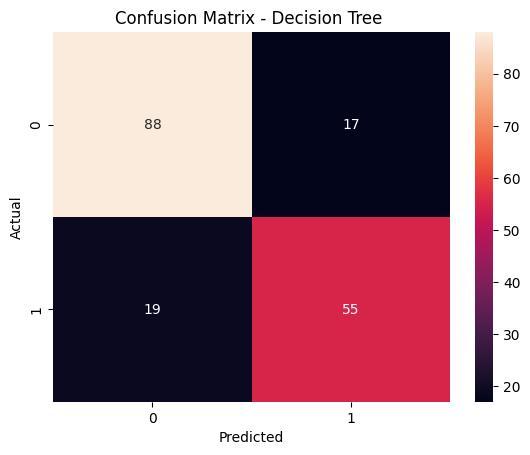

In [ ]:
print('Accuracy Score of Decision Tree:',accuracy_score(y_test,dt_pred))
print('Precision Score of Decision Tree:',precision_score(y_test,dt_pred))
print('Recall Score of Decision Tree:',recall_score(y_test,dt_pred))
print('F1 Score of Decision Tree:',f1_score(y_test,dt_pred))
cm_dt=confusion_matrix(y_test,dt_pred)

sns.heatmap(cm_dt,annot=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree ")

Accuracy Score of Naïve Bayes : 0.776536312849162
Precission Score of Naïve Bayes : 0.7297297297297297
Recall Score of Naïve Bayes : 0.7297297297297297
F1 Score of Naïve Bayes : 0.7297297297297297


Text(0.5, 1.0, 'Confusion Matrix - Naïve Bayes ')

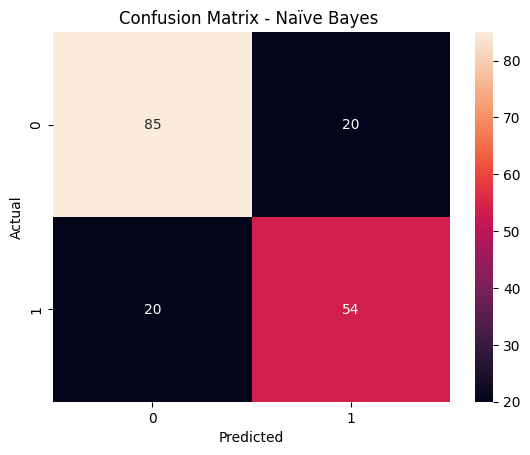

In [ ]:
print('Accuracy Score of Naïve Bayes :',accuracy_score(y_test,nb_pred))
print('Precission Score of Naïve Bayes :',precision_score(y_test,nb_pred))
print('Recall Score of Naïve Bayes :',recall_score(y_test,nb_pred))
print('F1 Score of Naïve Bayes :',f1_score(y_test,nb_pred))
cm_nb=confusion_matrix(y_test,nb_pred)

sns.heatmap(cm_nb,annot=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Naïve Bayes ")

Accuracy Score of Support Vector Machine  : 0.7821229050279329
Precission Score of Support Vector Machine: 0.7536231884057971
Recall Score of Support Vector Machine: 0.7027027027027027
F1 Score of Support Vector Machine: 0.7272727272727273


Text(0.5, 1.0, 'Confusion Matrix - Support Vector Machine')

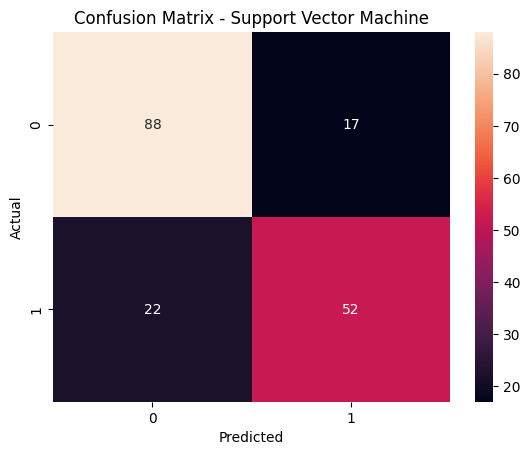

In [ ]:
print('Accuracy Score of Support Vector Machine  :',accuracy_score(y_test,svm_pred))
print('Precission Score of Support Vector Machine:',precision_score(y_test,svm_pred))
print('Recall Score of Support Vector Machine:',recall_score(y_test,svm_pred))
print('F1 Score of Support Vector Machine:',f1_score(y_test,svm_pred))
cm_svm=confusion_matrix(y_test,svm_pred)

sns.heatmap(cm_svm,annot=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Support Vector Machine")

Accuracy Score of Boosting: 0.7932960893854749
Precission Score of Boosting: 0.7605633802816901
Recall Score of Boosting: 0.7297297297297297
F1 Score of Boosting: 0.7448275862068966


Text(0.5, 1.0, 'Confusion Matrix - Boosting')

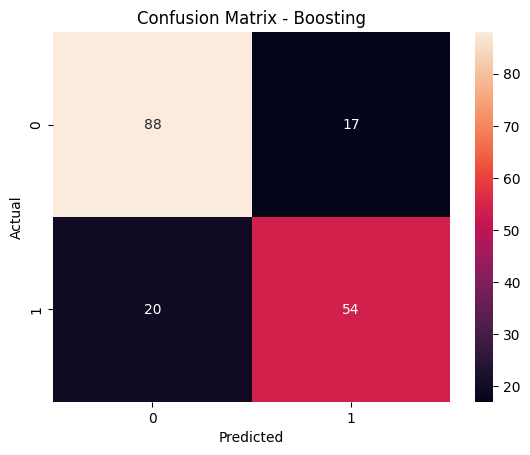

In [ ]:
print('Accuracy Score of Boosting:',accuracy_score(y_test,boosting_pred))
print('Precission Score of Boosting:',precision_score(y_test,boosting_pred))
print('Recall Score of Boosting:',recall_score(y_test,boosting_pred))
print('F1 Score of Boosting:',f1_score(y_test,boosting_pred))
cm_boost=confusion_matrix(y_test,boosting_pred)

sns.heatmap(cm_boost,annot=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Boosting")

In [ ]:
comparison_df=pd.DataFrame({
    "Decision Tree":[
        accuracy_score(y_test,dt_pred),
        precision_score(y_test,dt_pred),
        recall_score(y_test,dt_pred),
        f1_score(y_test,dt_pred)
    ],
    "Naive Bayes":[
        accuracy_score(y_test,nb_pred),
        precision_score(y_test,nb_pred),
        recall_score(y_test,nb_pred),
        f1_score(y_test,nb_pred)
    ],
    "SVM":[
        accuracy_score(y_test,svm_pred),
        precision_score(y_test,svm_pred),
        recall_score(y_test,svm_pred),
        f1_score(y_test,svm_pred)
    ],
    "AdaBoost":[
        accuracy_score(y_test,boosting_pred),
        precision_score(y_test,boosting_pred),
        recall_score(y_test,boosting_pred),
        f1_score(y_test,boosting_pred)
    ]
},
index=["Accuracy","Precision","Recall","F1"])


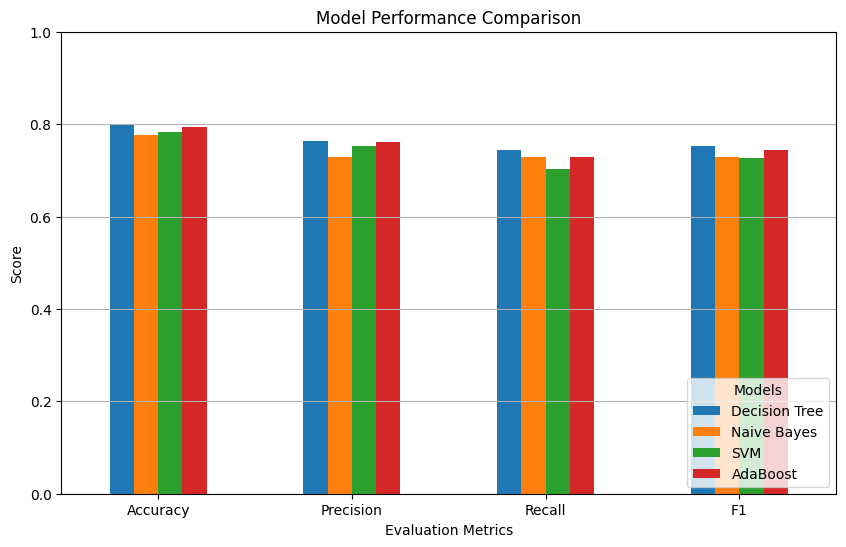

In [ ]:
comparison_df.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Evaluation Metrics")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.legend(title="Models",loc="lower right")
plt.grid(axis='y')
plt.show()


In this dataset or program Decision Tree CLassifier does better classification than every other but in mostly cases ensemble techniques gives better accuracy,etc with noisy data